In [1]:
import pandas as pd
df = pd.read_csv('customer 1-EDa-prj1 1.csv')
df.head()

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date
0,1,56.0,67700.0,1019.145669,Female,South,31.0,Toys,12.501082,2022-05-01,2022-02-27
1,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03
2,3,46.0,84000.0,354.742321,Male,East,25.0,Clothing,89.085761,2022-07-17,2022-04-13
3,4,32.0,42700.0,716.573913,Male,West,5.0,Electronics,98.800804,2022-07-09,2021-04-21
4,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02


In [9]:
df.isna().sum()

customer_id                   0
age                           6
income                        6
purchase_amount               6
gender                        7
region                        6
total_purchases               6
preferred_product_category    8
customer_loyalty_score        5
signup_date                   6
last_purchase_date            6
dtype: int64

In [10]:
df.dropna(inplace=True)

## removing outliers

In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Display original data info
print("Original dataset shape:", df.shape)
print("\nOriginal data statistics:")
print(df[['income', 'customer_loyalty_score']].describe())


df_clean = df.copy()


df_clean = remove_outliers_iqr(df_clean, 'income')
print(f"\nAfter removing income outliers: {df_clean.shape[0]} rows remaining")


df_clean = remove_outliers_iqr(df_clean, 'customer_loyalty_score')
print(f"After removing loyalty score outliers: {df_clean.shape[0]} rows remaining")

Original dataset shape: (3466, 12)

Original data statistics:
             income  customer_loyalty_score
count  3.466000e+03             3466.000000
mean   7.479331e+04               62.316692
std    1.924793e+05              362.441047
min   -5.000000e+04             -999.000000
25%    4.410000e+04               24.276272
50%    6.950000e+04               49.555804
75%    9.590000e+04               74.427861
max    9.999999e+06            15000.000000

After removing income outliers: 3460 rows remaining
After removing loyalty score outliers: 3443 rows remaining


In [23]:
df=df_clean.copy()

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


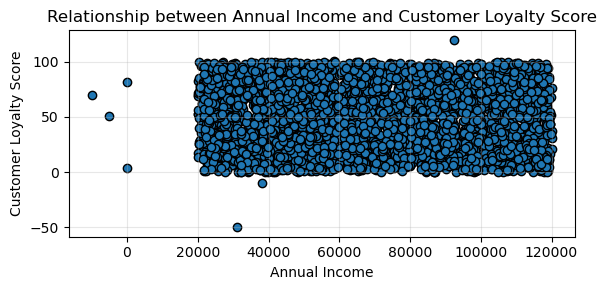

In [24]:

plt.figure(figsize=(6, 3))
plt.scatter(df['income'], df['customer_loyalty_score'], edgecolors='black')
plt.xlabel('Annual Income')
plt.ylabel('Customer Loyalty Score')
plt.title('Relationship between Annual Income and Customer Loyalty Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

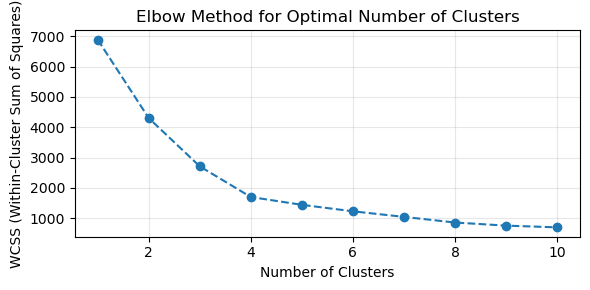

In [27]:

X = df[['income', 'customer_loyalty_score']].values

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS for different numbers of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(6, 3))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### no. of optimal clusters - 3

In [28]:

optimal_clusters = 4
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


print("Cluster assignments:", clusters)

Cluster assignments: [3 3 2 ... 0 3 1]


In [29]:
# Task 5: Add the cluster labels to the original dataset
df['cluster'] = clusters
print("Task 5: Cluster labels added to dataset")
print(df[['income', 'customer_loyalty_score', 'cluster']])

Task 5: Cluster labels added to dataset
        income  customer_loyalty_score  cluster
0      67700.0               12.501082        3
1      50200.0               14.402036        3
2      84000.0               89.085761        2
3      42700.0               98.800804        1
4     112300.0               28.893785        0
...        ...                     ...      ...
3521   37500.0                2.403770        3
3522  110800.0               72.893301        2
3523  108600.0               23.945481        0
3524   32200.0                6.470420        3
3525   49400.0               69.507195        1

[3443 rows x 3 columns]


In [30]:
df['cluster'].unique()

array([3, 2, 1, 0], dtype=int32)

In [31]:
# Task 6: Analyze which cluster corresponds to high-value customers (high income & high score)
#
cluster_analysis = df.groupby('cluster').agg({
    'income': 'mean',
    'customer_loyalty_score': 'mean',
    'age': 'count'  # to see number of customers in each cluster
}).rename(columns={'age': 'customer_count'})


In [32]:

print("Task 6: Cluster Analysis")
print("=" * 50)
print(cluster_analysis)


Task 6: Cluster Analysis
               income  customer_loyalty_score  customer_count
cluster                                                      
0        95851.807229               23.861798             830
1        45115.421115               75.650929             843
2        95170.348837               73.826977             860
3        44658.682418               25.394958             910



High-value customers are in Cluster 0
Cluster 0 characteristics:
  - Average Income: $95,851.81
  - Average Loyalty Score: 23.86
  - Number of Customers: 830


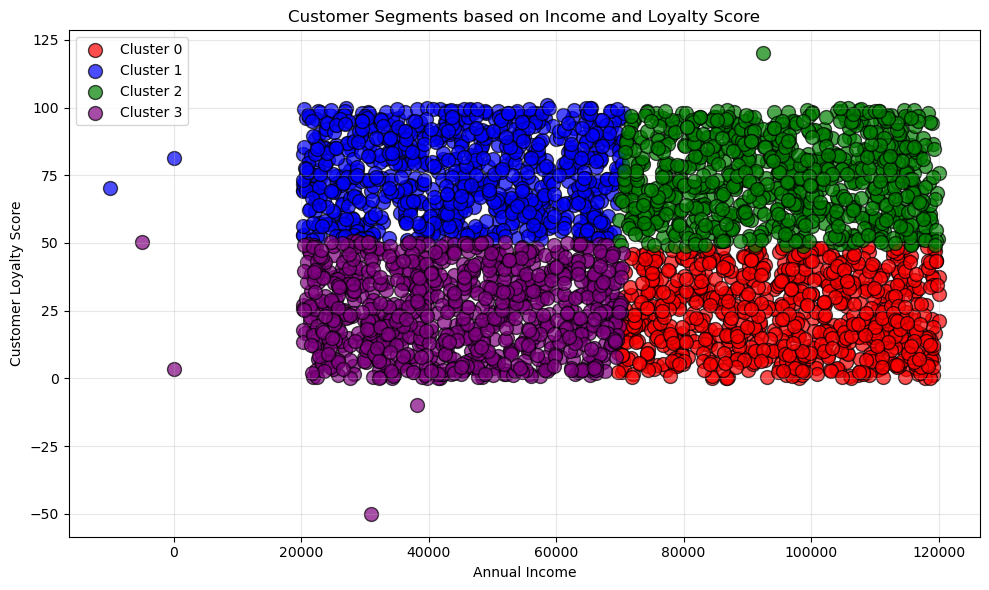

In [33]:

# Identify high-value cluster
cluster_analysis['combined_score'] = cluster_analysis['income'] + cluster_analysis['customer_loyalty_score']
high_value_cluster = cluster_analysis['combined_score'].idxmax()

print(f"\nHigh-value customers are in Cluster {high_value_cluster}")
print(f"Cluster {high_value_cluster} characteristics:")
print(f"  - Average Income: ${cluster_analysis.loc[high_value_cluster, 'income']:,.2f}")
print(f"  - Average Loyalty Score: {cluster_analysis.loc[high_value_cluster, 'customer_loyalty_score']:.2f}")
print(f"  - Number of Customers: {cluster_analysis.loc[high_value_cluster, 'customer_count']}")

# Visualize the clusters
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange']
for cluster_num in range(optimal_clusters):
    cluster_data = df[df['cluster'] == cluster_num]
    plt.scatter(cluster_data['income'], cluster_data['customer_loyalty_score'], 
                c=colors[cluster_num], label=f'Cluster {cluster_num}', s=100, alpha=0.7, edgecolors='black')

plt.xlabel('Annual Income')
plt.ylabel('Customer Loyalty Score')
plt.title('Customer Segments based on Income and Loyalty Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
df.head()

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date,cluster
0,1,56.0,67700.0,1019.145669,Female,South,31.0,Toys,12.501082,2022-05-01,2022-02-27,3
1,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03,3
2,3,46.0,84000.0,354.742321,Male,East,25.0,Clothing,89.085761,2022-07-17,2022-04-13,2
3,4,32.0,42700.0,716.573913,Male,West,5.0,Electronics,98.800804,2022-07-09,2021-04-21,1
4,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02,0


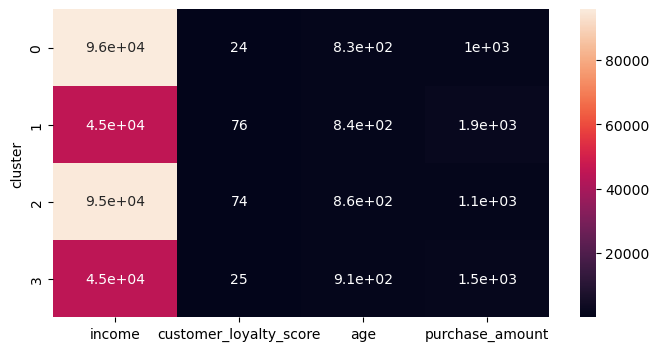

In [41]:
cluster_profile = df.groupby('cluster').agg({
    'income': 'mean',
    'customer_loyalty_score': 'mean',
    'age': 'count',
    'purchase_amount':'mean'  # to see number of customers in each cluster
})
plt.figure(figsize=(8,4))
sns.heatmap(cluster_profile,annot=True)
plt.show()


### high income individuals comes under cluster 0 , lower ones in 3 and 1

## cluster 2 is with both conditions met - high income and high loyality score